In [2]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, r2_score
from tqdm import tqdm_notebook
from itertools import product
from typing import Union
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [20, 10]
%matplotlib inline


In [3]:
# Read data
df = pd.read_csv('../datasets/TX-Data/met-cleanedup/met_data1_cleaned.csv', sep=",", parse_dates=["Date"], index_col="Date")

In [4]:
df.last('3D')

,Ppt,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,
2021-08-29 01:00:00,0.0,22.510,91.50,0.404,209.700000,0.0
2021-08-29 02:00:00,0.0,22.090,95.10,1.648,188.800000,0.0
2021-08-29 03:00:00,0.0,21.750,96.10,0.077,106.833333,0.0
2021-08-29 04:00:00,0.0,21.620,97.00,0.099,186.000000,0.0
2021-08-29 05:00:00,0.0,21.690,97.40,0.364,169.000000,0.0
...,...,...,...,...,...,...
2021-08-31 20:00:00,0.0,29.100,60.19,1.029,197.100000,0.0
2021-08-31 21:00:00,0.0,29.595,62.28,0.510,199.600000,0.0
2021-08-31 22:00:00,0.0,27.730,63.98,NaN,192.600000,0.0


In [5]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['Tair'] = df['Tair'].astype(float)
    df['RH'] = df['RH'].astype(float)
    df['Windspeed'] = df['Windspeed'].astype(float)
    df['Winddirection'] = df['Winddirection'].astype(float)
    df['Srad'] = df['Srad'].astype(float)  

In [6]:
# remove column name spaces of each DataFrame 
remove_spaces(df)
    
    

In [7]:
# create df with only Air temp data of each Station
df_Tair = df["Tair"]
df_Tair

Date
2014-10-01 00:00:00    22.130
2014-10-01 01:00:00    21.680
2014-10-01 02:00:00    22.210
2014-10-01 03:00:00    22.410
2014-10-01 04:00:00    22.300
                        ...  
2021-08-31 20:00:00    29.100
2021-08-31 21:00:00    29.595
2021-08-31 22:00:00    27.730
2021-08-31 23:00:00    27.300
2021-09-01 00:00:00    26.210
Name: Tair, Length: 60649, dtype: float64

In [8]:
# Exclude data with dates before 2015
reindex_df_Tair = df_Tair[(df_Tair.index > "2014-12-31 23:00")]

In [9]:
# Fill nan values
reindex_df_Tair.replace([np.inf, -np.inf], np.nan, inplace=True)
reindex_df_Tair.fillna(reindex_df_Tair.mean(), inplace=True)

reindex_df_Tair

Date
2015-01-01 00:00:00    -1.090
2015-01-01 01:00:00    -1.038
2015-01-01 02:00:00    -0.981
2015-01-01 03:00:00    -0.814
2015-01-01 04:00:00    -0.805
                        ...  
2021-08-31 20:00:00    29.100
2021-08-31 21:00:00    29.595
2021-08-31 22:00:00    27.730
2021-08-31 23:00:00    27.300
2021-09-01 00:00:00    26.210
Name: Tair, Length: 58441, dtype: float64

In [10]:
update_df_Tair = reindex_df_Tair.resample('12H').mean()

Text(0, 0.5, 'Tair Data in Celsius')

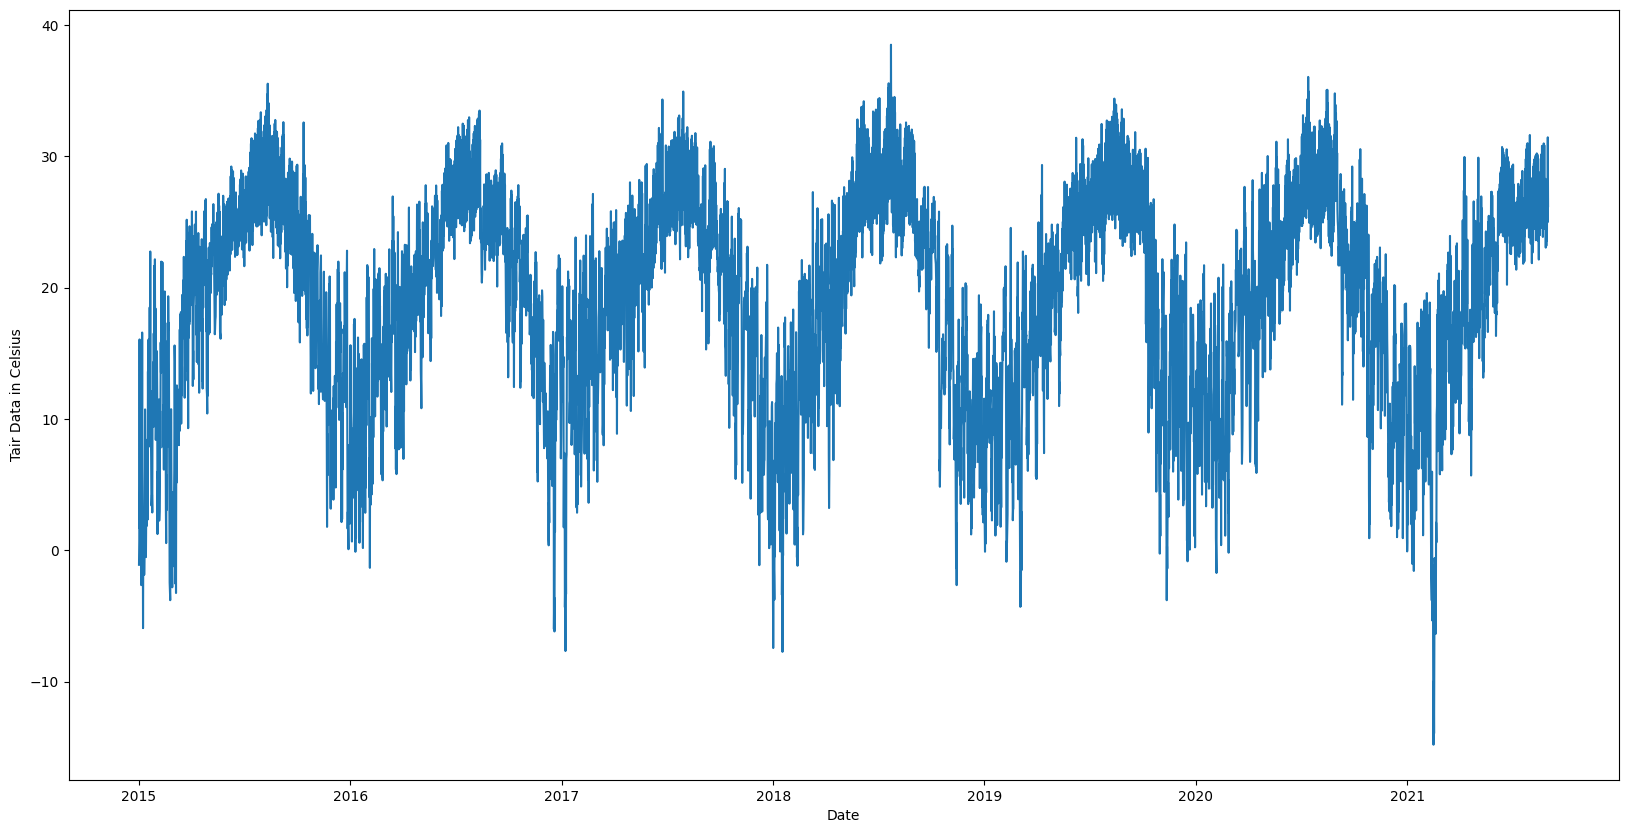

In [11]:
fig, ax = plt.subplots()

ax.plot(update_df_Tair)
ax.set_xlabel('Date')
ax.set_ylabel('Tair Data in Celsius')

    

In [12]:
# stationarity test for stations
ad_fuller_result = adfuller(update_df_Tair)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}\n')

ADF Statistic: -3.5137379297548312
p-value: 0.007641205483870306



In [13]:
# Train/Test Split
train = update_df_Tair[:'2019-12-31 23:00']
test = update_df_Tair['2019-12-31 23:00':]

In [14]:
# Defining optimize_SARIMAX function
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int)->pd.DataFrame:

    results=[]
    
    for order in tqdm_notebook(order_list):
        try:
            model = SARIMAX(
            endog,
            exog,
            order=(order[0], d, order[1]),
            seasonal_order=(order[2], D, order[3], s),
            simple_differencing=False).fit(disp=False)
        except:
            continue
        
        results.append([order, model.aic])
    
    result_df=pd.DataFrame(results)
    result_df.columns = ['(p, q, P, Q)', 'AIC']
    
    # Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [15]:
# Define range of values for p, q, P, and Q

ps= range(0, 3, 1)
qs= range(0, 3, 1)
Ps= range(0, 3, 1)
Qs= range(0, 3, 1)

# Create list of all unique combinations
order_list = list(product(ps, qs, Ps, Qs))

# Set constants
d=0
D=0
s=12

In [16]:
# Find the (p, d, q) (P, D, Q)m comination with the lowpyuvuest AIC
SARIMA_result_df = optimize_SARIMAX(train, None, order_list, d, D, s)

  0%|          | 0/81 [00:00<?, ?it/s]

In [17]:
result_array=SARIMA_result_df.to_numpy()
optimal_parameters = result_array[0]
print(result_array)

[[(2, 1, 1, 2) 18440.352803556474]
 [(2, 1, 1, 1) 18441.14800254295]
 [(2, 1, 2, 2) 18443.229939139404]
 [(2, 2, 1, 1) 18443.7271792241]
 [(2, 1, 2, 1) 18444.01027044611]
 [(2, 2, 2, 2) 18445.11365223868]
 [(2, 2, 1, 2) 18453.28484111974]
 [(2, 2, 2, 1) 18454.760880644117]
 [(2, 2, 0, 0) 18536.821626674777]
 [(2, 2, 1, 0) 18538.807521889757]
 [(2, 2, 0, 1) 18538.80763142805]
 [(2, 2, 0, 2) 18540.758134047697]
 [(2, 2, 2, 0) 18542.48531347845]
 [(1, 2, 1, 1) 18550.1470117583]
 [(1, 2, 1, 2) 18552.047356719737]
 [(1, 2, 2, 1) 18552.04957145089]
 [(1, 2, 2, 2) 18553.896193739245]
 [(2, 1, 0, 0) 18563.80951757532]
 [(2, 1, 0, 1) 18565.38055935074]
 [(2, 1, 2, 0) 18567.071781636136]
 [(2, 1, 0, 2) 18567.099974276338]
 [(2, 0, 2, 1) 18630.297669114632]
 [(2, 0, 1, 2) 18634.68556211113]
 [(2, 0, 1, 1) 18635.24272122327]
 [(2, 0, 2, 2) 18639.238638882227]
 [(1, 1, 1, 1) 18660.127612146243]
 [(1, 1, 2, 1) 18660.40157193121]
 [(1, 1, 1, 2) 18660.492473637798]
 [(1, 1, 2, 2) 18664.126176850976]
 

In [18]:
# Fit optimal model to study its residuals
SARIMA_model = SARIMAX(train, order=(result_array[0][0][0], 0, result_array[0][0][1]), seasonal_order = (result_array[0][0][2], 0, result_array[0][0][3], 12), enforce_invertibility=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)
print(SARIMA_model_fit.summary())

                                        SARIMAX Results                                        
Dep. Variable:                                    Tair   No. Observations:                 3652
Model:             SARIMAX(2, 0, 1)x(1, 0, [1, 2], 12)   Log Likelihood               -9233.145
Date:                                 Fri, 16 Jun 2023   AIC                          18480.290
Time:                                         11:34:53   BIC                          18523.711
Sample:                                     01-01-2015   HQIC                         18495.753
                                          - 12-31-2019                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0047      0.019      0.247      0.805      -0.032       0

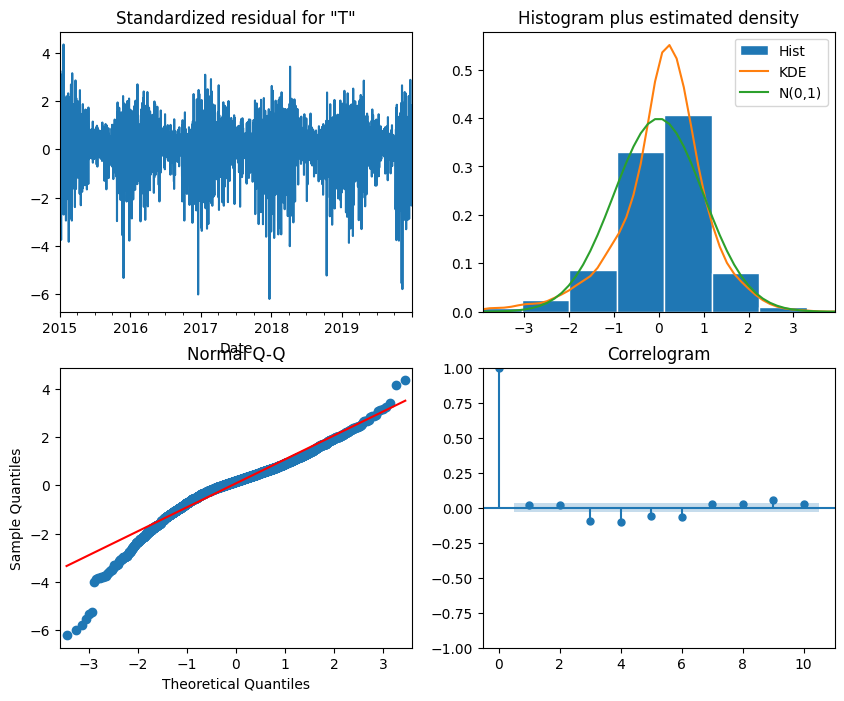

In [19]:
# Plot residual's diagnostics
SARIMA_model_fit.plot_diagnostics(figsize=(10,8));

In [20]:
# Run the Ljung-Box test
residuals = SARIMA_model_fit.resid
lbvalue, pvalue = acorr_ljungbox(residuals, np.arange(1, 3, 1))
    
# Print p-values
print(pvalue)


lb_pvalue


In [21]:
# Function to preform rolling forcasts
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:

    total_len = train_len + horizon
    end_idx = train_len
    
    if method == 'last_season':
        pred_last_season=[]
        
        for i in range(train_len, total_len, window):
            last_season = update_df_Tair[i-window:i].values
            pred_last_season.extend(last_season)
            
        return pred_last_season
    
    elif method == 'SARIMA':
        pred_SARIMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(update_df_Tair[:i], order=(result_array[0][0][0], 0, result_array[0][0][1]), seasonal_order = (result_array[0][0][2], 0, result_array[0][0][3], 12), simple_differencing=True)
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_SARIMA.extend(oos_pred)
        
        return pred_SARIMA

In [22]:
actual_vals = update_df_Tair['2020-12-31 11:00':]

In [23]:
# Define length of training set, horizon of forecast, and the window of forecast
TRAIN_LEN = 4384
HORIZON = 488
WINDOW = 61



# Preform rolling forecast with the naive seasonal baseline
pred_df_array = rolling_forecast(update_df_Tair, TRAIN_LEN, HORIZON, WINDOW, 'last_season')
SARIMA_df_array = rolling_forecast(update_df_Tair, TRAIN_LEN, HORIZON, WINDOW, 'SARIMA')

#Display the predictions
# print(SARIMA_df_array)
# print(pred_df_array)

[-0.6231204380967242, 2.9936051874915592, 1.2763366624761037, 5.512719427026875, 3.16766391130482, 7.139422934562429, 5.060348676069899, 9.534570235192318, 6.533380715697462, 10.731586627667797, 7.379143590242633, 11.415534490968138, 8.324479540854226, 12.896974875126213, 8.994183370054106, 13.932197646042264, 9.812256777158343, 14.383681084961822, 10.816108887172703, 15.803388652042674, 11.521279143633791, 16.675227325734127, 12.380683120283384, 16.874629759208588, 12.839187378291399, 17.60505269246083, 12.926726304475846, 17.994064188754432, 13.236034104957726, 17.889275166684058, 13.795569841102562, 18.829493360009895, 14.113085355341896, 19.288176802735652, 14.634364605624848, 19.131493947597203, 14.798247125296351, 19.554604746751817, 14.629213602187901, 19.678498369361506, 14.71504391552566, 19.344977390165003, 15.07998320572654, 20.087398801867764, 15.228231290190832, 20.37533292982303, 15.602215468472796, 20.07127823492931, 15.638102484776779, 20.36687299931358, 15.357892074573

Text(0, 0.5, 'Tair Data in Celsius')

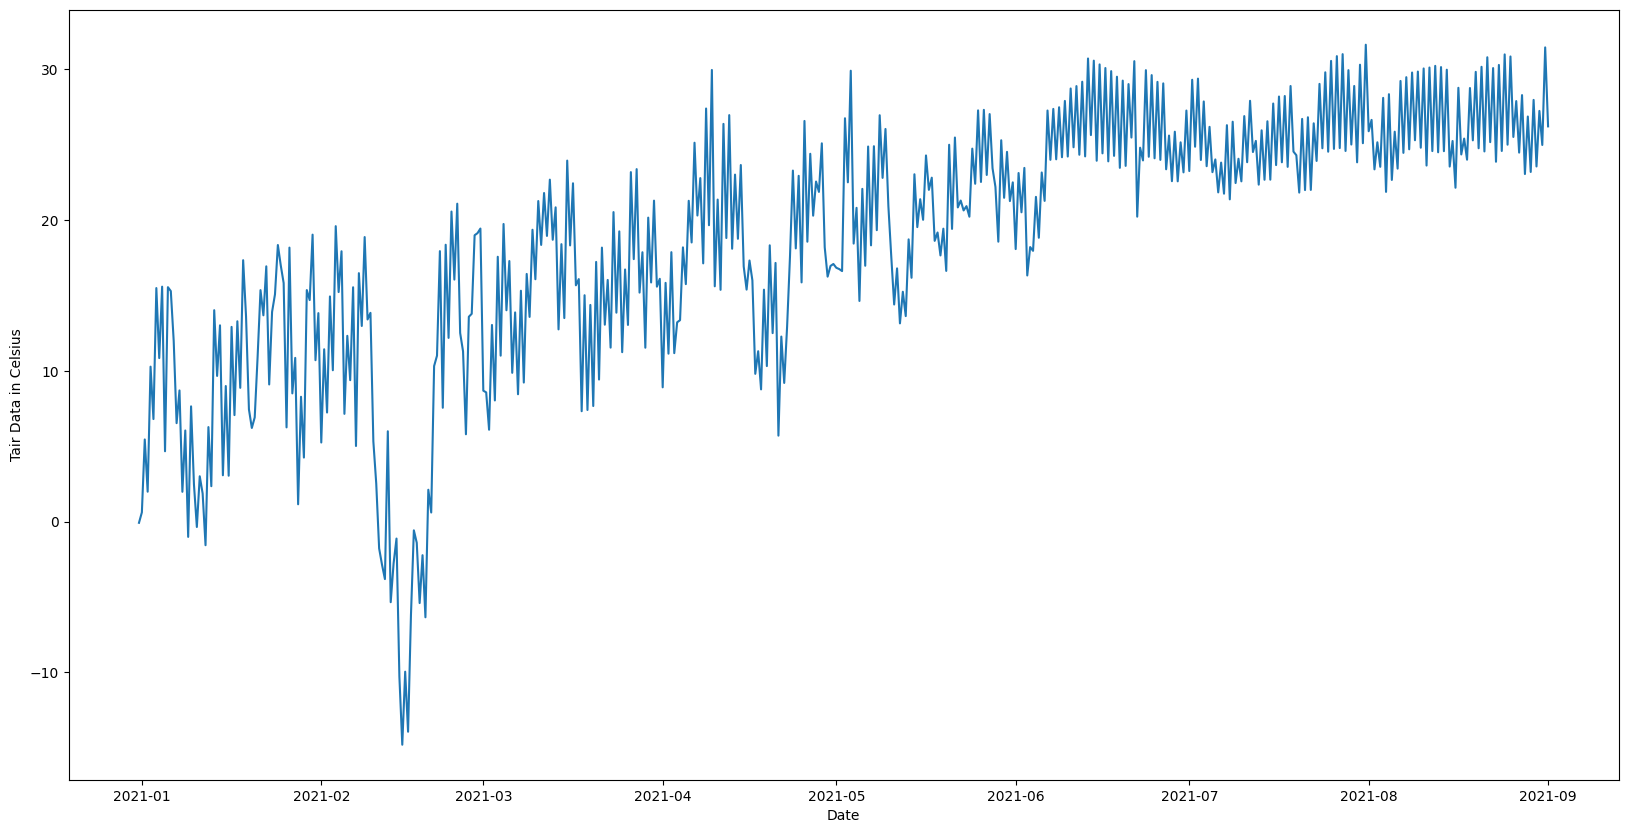

In [24]:
fig, ax = plt.subplots()

ax.plot(actual_vals)
ax.set_xlabel('Date')
ax.set_ylabel('Tair Data in Celsius')

Text(0, 0.5, 'Tair Data in Celsius')

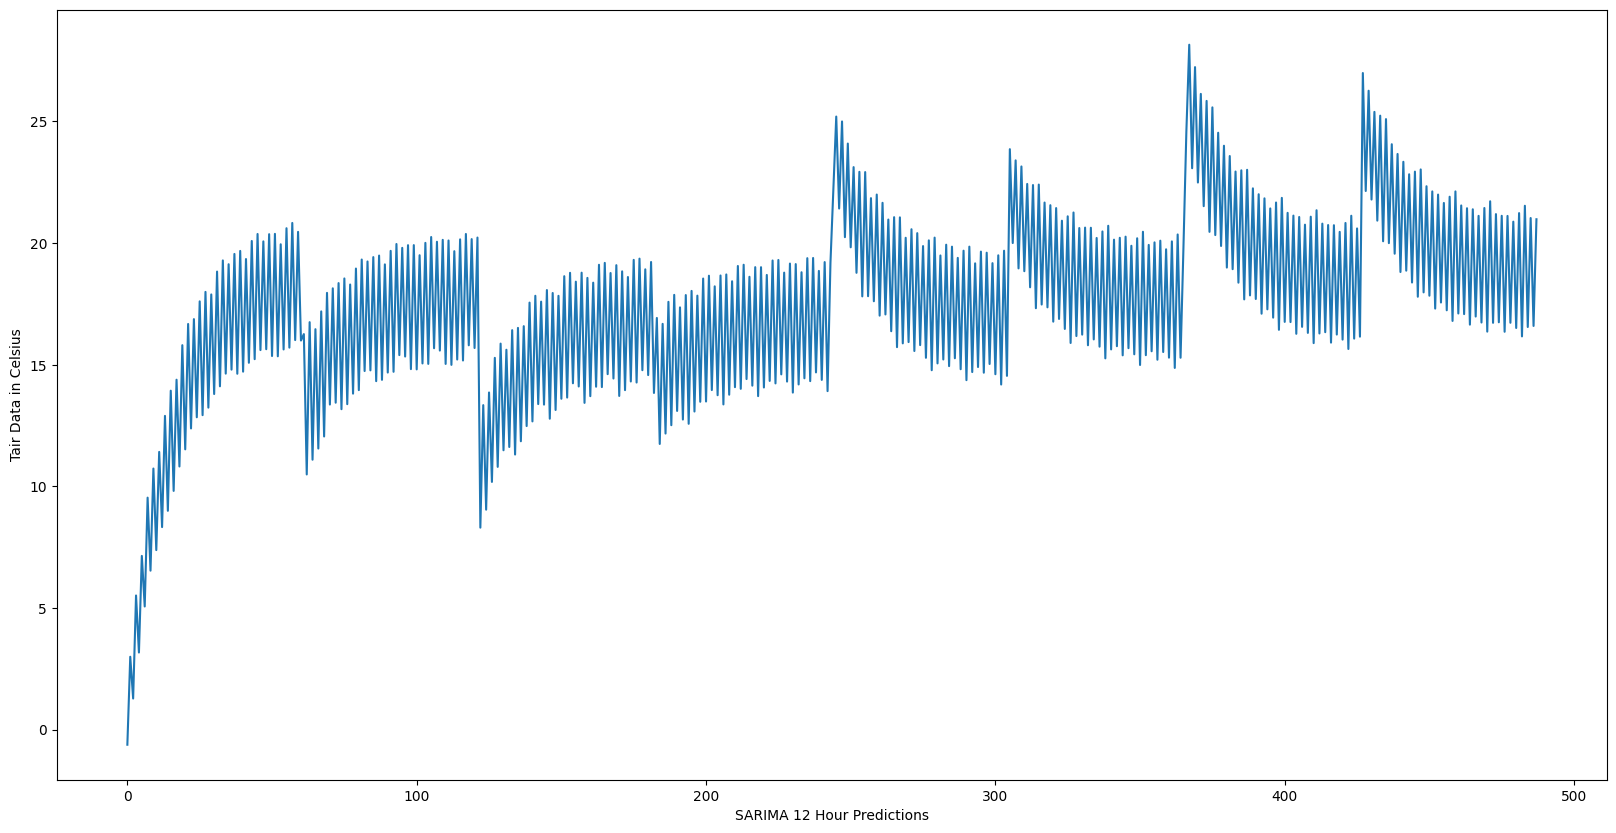

In [29]:
fig, ax = plt.subplots()

ax.plot(SARIMA_df_array)
ax.set_xlabel('SARIMA 12 Hour Predictions')
ax.set_ylabel('Tair Data in Celsius')

In [26]:
# mean squared error
def calculate_mse(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    return mse

In [27]:
# r squared
def calculate_r_squared(actual, predicted):
    r_squared = r2_score(actual, predicted)
    return r_squared

In [28]:
mse = calculate_mse(actual_vals, SARIMA_df_array)
r_squared = calculate_r_squared(actual_vals, SARIMA_df_array)

print("Mean Squared Error:", mse)
print("R-squared:", r_squared)

Mean Squared Error: 74.9087278027376
R-squared: -0.015723556980850706
